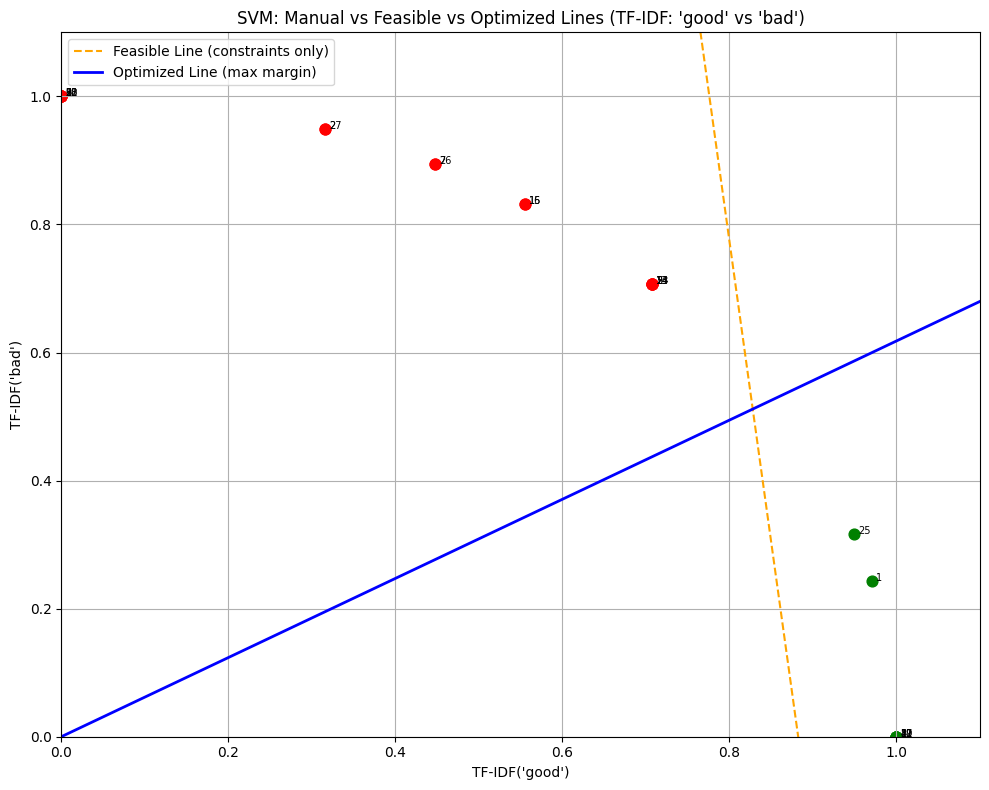

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import cvxpy as cp
from ortools.linear_solver import pywraplp

# === Large dataset with "good"/"bad" patterns ===
sentences = [
    "good good good good bad",
    "bad bad bad good", 
    "bad bad bad", 
    "good good", 
    "good bad", 
    "bad bad", 
    "good bad bad", 
    "good good good",
    "bad bad bad bad", 
    "good good good good", 
    "bad", 
    "good", 
    "bad bad good good",
    "good good bad bad", 
    "bad bad bad good good", 
    "good good bad bad bad", 
    "good", 
    "bad",
    "good good", 
    "bad bad", 
    "good good good", 
    "bad bad bad", 
    "good bad", 
    "bad good",
    "good good good bad", 
    "bad bad good", 
    "bad bad bad good"
]
labels = [1 if s.count("good") > s.count("bad") else -1 for s in sentences]  # Auto-label based on majority

# === TF-IDF vectorization ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Manual weight (adjust freely) ===
w_manual = np.array([1, -1])
b_manual = 0

# === Feasible w using Google OR-Tools ===
solver = pywraplp.Solver.CreateSolver('GLOP')
w1 = solver.NumVar(-10, 10, 'w1')
w2 = solver.NumVar(-10, 10, 'w2')
b_lin = solver.NumVar(-10, 10, 'b')

for i in range(len(X)):
    x1, x2 = X[i]
    y = labels[i]
    solver.Add(y * (w1 * x1 + w2 * x2 + b_lin) >= 1)

solver.Minimize(0)  # Just satisfy constraints
status = solver.Solve()
w_feasible = np.array([w1.solution_value(), w2.solution_value()])
b_feasible = b_lin.solution_value()

# === Optimized w using CVXPY ===
w_cvx = cp.Variable(2)
b_cvx = cp.Variable()
constraints = [labels[i] * (X[i] @ w_cvx + b_cvx) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w_cvx, 2))
problem = cp.Problem(objective, constraints)
problem.solve()
w_opt = w_cvx.value
b_opt = b_cvx.value

# === Plotting ===
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=60)
    ax.text(X[i, 0] + 0.005, X[i, 1], f"{i+1}", fontsize=7)

x_vals = np.linspace(0, 1.2, 200)

# Manual
# if w_manual[1] != 0:
#     y_manual = -(w_manual[0] * x_vals + b_manual) / w_manual[1]
#     ax.plot(x_vals, y_manual, 'k--', label="Manual Line")

# Feasible
if w_feasible[1] != 0:
    y_feasible = -(w_feasible[0] * x_vals + b_feasible) / w_feasible[1]
    ax.plot(x_vals, y_feasible, 'orange', linestyle='--', label="Feasible Line (constraints only)")

# Optimized
if w_opt[1] != 0:
    y_opt = -(w_opt[0] * x_vals + b_opt) / w_opt[1]
    ax.plot(x_vals, y_opt, 'blue', linewidth=2, label="Optimized Line (max margin)")

# Labels and layout
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("SVM: Manual vs Feasible vs Optimized Lines (TF-IDF: 'good' vs 'bad')")
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


🟧 Feasible weights: w = [10.          1.06366715], b = -8.823194067603787
🟦 Optimized weights: w = [ 2.28824556 -3.70245921], b = 6.430609642751788e-08


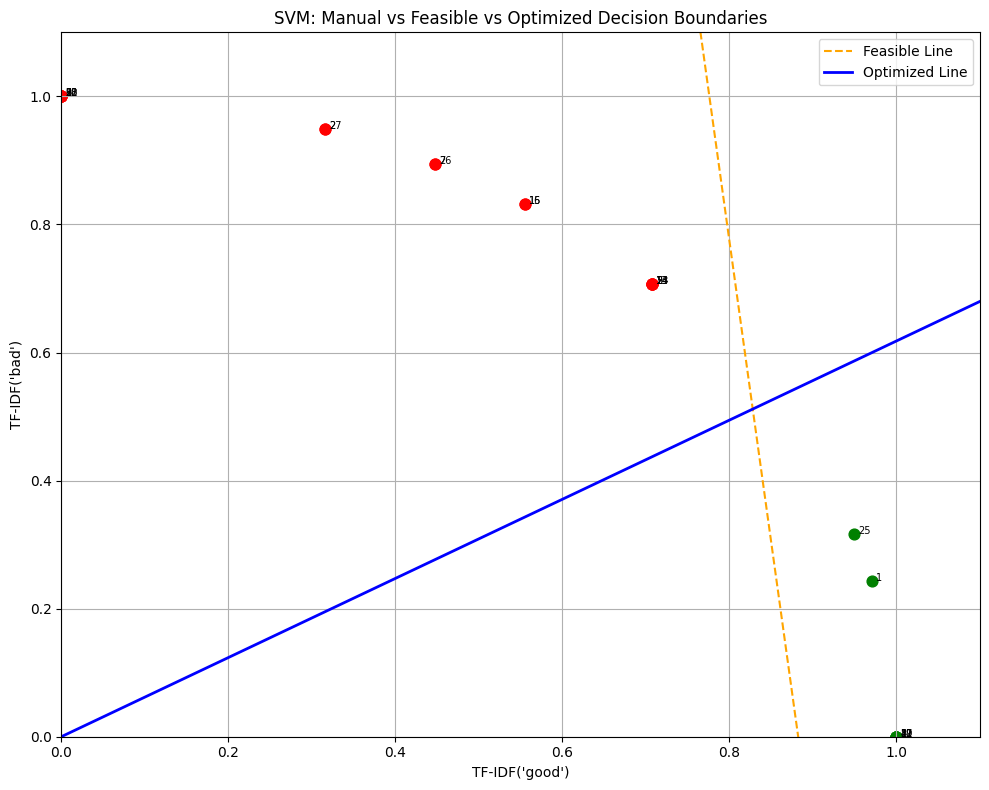

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import cvxpy as cp
from ortools.linear_solver import pywraplp

# === Large dataset (unique sentences only) ===
sentences = [
    "good good good good bad",
    "bad bad bad good", 
    "bad bad bad", 
    "good good", 
    "good bad", 
    "bad bad", 
    "good bad bad", 
    "good good good",
    "bad bad bad bad", 
    "good good good good", 
    "bad", 
    "good", 
    "bad bad good good",
    "good good bad bad", 
    "bad bad bad good good", 
    "good good bad bad bad", 
    "good", 
    "bad",
    "good good", 
    "bad bad", 
    "good good good", 
    "bad bad bad", 
    "good bad", 
    "bad good",
    "good good good bad", 
    "bad bad good", 
    "bad bad bad good"
]
labels = [1 if s.count("good") > s.count("bad") else -1 for s in sentences]

# === TF-IDF vectorization ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Manual weights (you can change them)
w_manual = np.array([1, -1])
b_manual = 0

# === Feasible line using Google OR-Tools ===
solver = pywraplp.Solver.CreateSolver('GLOP')
w1 = solver.NumVar(-10, 10, 'w1')
w2 = solver.NumVar(-10, 10, 'w2')
b_lin = solver.NumVar(-10, 10, 'b')

for i in range(len(X)):
    x1, x2 = X[i]
    y = labels[i]
    solver.Add(y * (w1 * x1 + w2 * x2 + b_lin) >= 1)

solver.Minimize(0)  # Just find a feasible solution
status = solver.Solve()
w_feasible = np.array([w1.solution_value(), w2.solution_value()])
b_feasible = b_lin.solution_value()

print(f"🟧 Feasible weights: w = {w_feasible}, b = {b_feasible}")

# === Optimized line using CVXPY ===
w_cvx = cp.Variable(2)
b_cvx = cp.Variable()
constraints = [labels[i] * (X[i] @ w_cvx + b_cvx) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w_cvx, 2))
problem = cp.Problem(objective, constraints)
problem.solve()

w_opt = w_cvx.value
b_opt = b_cvx.value

print(f"🟦 Optimized weights: w = {w_opt}, b = {b_opt}")

# === Plotting ===
fig, ax = plt.subplots(figsize=(10, 8))

for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=60)
    ax.text(X[i, 0] + 0.005, X[i, 1], f"{i+1}", fontsize=7)

x_vals = np.linspace(0, 1.2, 200)

# Manual decision boundary
# if w_manual[1] != 0:
#     y_manual = -(w_manual[0] * x_vals + b_manual) / w_manual[1]
#     ax.plot(x_vals, y_manual, 'k--', label="Manual Line")

# Feasible decision boundary
if w_feasible[1] != 0:
    y_feasible = -(w_feasible[0] * x_vals + b_feasible) / w_feasible[1]
    ax.plot(x_vals, y_feasible, 'orange', linestyle='--', label="Feasible Line")

# Optimized decision boundary
if w_opt[1] != 0:
    y_opt = -(w_opt[0] * x_vals + b_opt) / w_opt[1]
    ax.plot(x_vals, y_opt, 'blue', linewidth=2, label="Optimized Line")

# Final layout
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("SVM: Manual vs Feasible vs Optimized Decision Boundaries")
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


🟧 Feasible weights: w = [10.         -0.48787698], b = -7.726086692797363
🟦 Optimized weights: w = [ 3.65037139 -5.0644303 ], b = -0.00010935697553616657


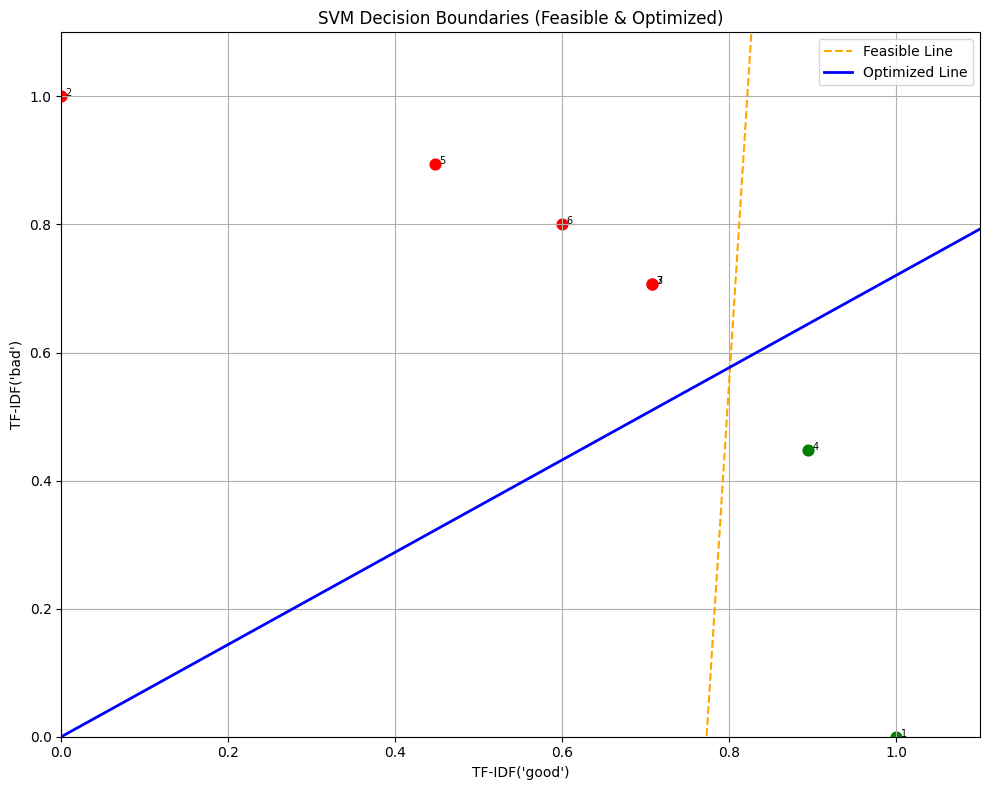

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import cvxpy as cp
from ortools.linear_solver import pywraplp

# === Unique dataset with "good"/"bad" mix ===
sentences = [
    "good good",
    "bad bad",
    "good bad",
    "good good good good bad bad",
    "bad bad bad bad good good",
    "bad bad bad bad good good good",
    "good good good good bad bad bad bad",
]

labels = [1 if s.count("good") > s.count("bad") else -1 for s in sentences]

# === TF-IDF vectorization ===
vectorizer = TfidfVectorizer(vocabulary=["good", "bad"])
X = vectorizer.fit_transform(sentences).toarray()

# === Manual line (editable)
w_manual = np.array([1, -1])
b_manual = 0

# === Feasible solution using Google OR-Tools
solver = pywraplp.Solver.CreateSolver('GLOP')
w1 = solver.NumVar(-10, 10, 'w1')
w2 = solver.NumVar(-10, 10, 'w2')
b_lin = solver.NumVar(-10, 10, 'b')

for i in range(len(X)):
    x1, x2 = X[i]
    y = labels[i]
    solver.Add(y * (w1 * x1 + w2 * x2 + b_lin) >= 1)

solver.Minimize(0)
solver.Solve()
w_feasible = np.array([w1.solution_value(), w2.solution_value()])
b_feasible = b_lin.solution_value()

print(f"🟧 Feasible weights: w = {w_feasible}, b = {b_feasible}")

# === Optimized solution using CVXPY
w_cvx = cp.Variable(2)
b_cvx = cp.Variable()
constraints = [labels[i] * (X[i] @ w_cvx + b_cvx) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w_cvx, 2))
problem = cp.Problem(objective, constraints)
problem.solve()
w_opt = w_cvx.value
b_opt = b_cvx.value

print(f"🟦 Optimized weights: w = {w_opt}, b = {b_opt}")

# === Plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Plot individual points
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    ax.scatter(X[i, 0], X[i, 1], color=color, s=60)
    ax.text(X[i, 0] + 0.005, X[i, 1], f"{i+1}", fontsize=7)

# Plot decision boundaries
x_vals = np.linspace(0, 1.2, 200)

# Optional manual line (uncomment if you want it)
# if w_manual[1] != 0:
#     y_manual = -(w_manual[0] * x_vals + b_manual) / w_manual[1]
#     ax.plot(x_vals, y_manual, 'k--', label="Manual Line")

if w_feasible[1] != 0:
    y_feasible = -(w_feasible[0] * x_vals + b_feasible) / w_feasible[1]
    ax.plot(x_vals, y_feasible, 'orange', linestyle='--', label="Feasible Line")

if w_opt[1] != 0:
    y_opt = -(w_opt[0] * x_vals + b_opt) / w_opt[1]
    ax.plot(x_vals, y_opt, 'blue', linewidth=2, label="Optimized Line")

# Final layout
ax.set_xlabel("TF-IDF('good')")
ax.set_ylabel("TF-IDF('bad')")
ax.set_title("SVM Decision Boundaries (Feasible & Optimized)")
ax.set_xlim(0, 1.1)
ax.set_ylim(0, 1.1)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()


In [17]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import cvxpy as cp
from ortools.linear_solver import pywraplp
import plotly.graph_objects as go

# === Sentences using 3 keywords
sentences = [
    "good good good neutral",
    "bad bad bad neutral",
    "good neutral neutral bad",
    "good good bad",
    "bad bad good neutral",
    "neutral neutral neutral",
    "good good neutral bad bad",
    "good neutral",
    "bad neutral",
    "good good good bad bad neutral"
]

# === Labeling: +1 if more "good", -1 if more "bad"
def label_sentence(s):
    g = s.count("good")
    b = s.count("bad")
    return 1 if g > b else -1 if b > g else 0

labels = np.array([label_sentence(s) for s in sentences])
sentences = [s for i, s in enumerate(sentences) if labels[i] != 0]
labels = labels[labels != 0]

# === TF-IDF Vectorization
vectorizer = TfidfVectorizer(vocabulary=["good", "bad", "neutral"])
X = vectorizer.fit_transform(sentences).toarray()

# === Feasible weights using OR-Tools
solver = pywraplp.Solver.CreateSolver('GLOP')
w1 = solver.NumVar(-10, 10, 'w1')
w2 = solver.NumVar(-10, 10, 'w2')
w3 = solver.NumVar(-10, 10, 'w3')
b_lin = solver.NumVar(-10, 10, 'b')

for i in range(len(X)):
    x1, x2, x3 = X[i]
    y = labels[i]
    solver.Add(y * (w1 * x1 + w2 * x2 + w3 * x3 + b_lin) >= 1)

solver.Minimize(0)
solver.Solve()
w_feasible = np.array([w1.solution_value(), w2.solution_value(), w3.solution_value()])
b_feasible = b_lin.solution_value()

# === Optimized weights using CVXPY
w_opt = cp.Variable(3)
b_opt = cp.Variable()
constraints = [labels[i] * (X[i] @ w_opt + b_opt) >= 1 for i in range(len(X))]
objective = cp.Minimize(cp.norm(w_opt, 2))
problem = cp.Problem(objective, constraints)
problem.solve()
w_opt = w_opt.value
b_opt = b_opt.value

# === 3D Visualization with Plotly
fig = go.Figure()

# Plot points
for i in range(len(X)):
    color = 'green' if labels[i] == 1 else 'red'
    fig.add_trace(go.Scatter3d(
        x=[X[i, 0]], y=[X[i, 1]], z=[X[i, 2]],
        mode='markers+text',
        marker=dict(size=5, color=color),
        name=f"Sentence {i+1}",
        text=[str(i+1)],
        textposition="top center"
    ))

# Meshgrid for decision planes
xx, yy = np.meshgrid(np.linspace(0, 1.2, 10), np.linspace(0, 1.2, 10))

# Feasible Plane
zz_feasible = -(w_feasible[0] * xx + w_feasible[1] * yy + b_feasible) / w_feasible[2]
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz_feasible, showscale=False, opacity=0.3,
    colorscale=[[0, 'orange'], [1, 'orange']], name='Feasible Plane'
))

# Optimized Plane
zz_optimized = -(w_opt[0] * xx + w_opt[1] * yy + b_opt) / w_opt[2]
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz_optimized, showscale=False, opacity=0.3,
    colorscale=[[0, 'blue'], [1, 'blue']], name='Optimized Plane'
))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title="TF-IDF('good')",
        yaxis_title="TF-IDF('bad')",
        zaxis_title="TF-IDF('neutral')"
    ),
    title="SVM: Feasible vs Optimized Hyperplanes (3D)",
    showlegend=True
)

# Save to HTML
fig.write_html("svm_3d_plot.html")
print("✅ 3D interactive plot saved as 'svm_3d_plot.html'")


✅ 3D interactive plot saved as 'svm_3d_plot.html'
